In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("fitness_activites.csv")

In [6]:
df.shape

(92, 4)

In [4]:
df.head()

,Date,Activity_Type,Duration,Calories_Burned
0,2024-01-01,Running,30,220
1,2024-01-02,Yoga,20,100
2,2024-01-03,Cycling,40,320
3,2024-01-04,Walking,25,120
4,2024-01-05,Running,35,250


In [5]:
df.tail()

,Date,Activity_Type,Duration,Calories_Burned
87,2024-03-28,Walking,20,100
88,2024-03-29,Running,25,210
89,2024-03-30,Yoga,15,80
90,2024-03-31,Cycling,50,390
91,2024-04-01,Walking,30,140


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Date             92 non-null     object
 1   Activity_Type    92 non-null     object
 2   Duration         92 non-null     int64 
 3   Calories_Burned  92 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 3.0+ KB


In [8]:
df.describe()

,Duration,Calories_Burned
count,92.000000,92.000000
mean,30.054348,198.695652
std,10.068299,103.182516
min,15.000000,70.000000
25%,23.750000,107.500000
50%,30.000000,170.000000
75%,36.250000,285.000000
max,50.000000,400.000000


In [10]:
df.isnull().sum()

,0
Date,0
Activity_Type,0
Duration,0
Calories_Burned,0


In [11]:
df.columns

Index(['Date', 'Activity_Type', 'Duration', 'Calories_Burned'], dtype='object')

In [14]:
df["Calories_Burned"].sum()

np.int64(18280)

Average Workout Duration

In [15]:
np.mean(df["Duration"])

np.float64(30.054347826086957)

Average Workout Duration

In [16]:
df.groupby("Activity_Type")["Duration"].sum()

,Duration
Activity_Type,
Cycling,985
Running,740
Walking,525
Yoga,515


In [17]:
df["Activity_Type"].value_counts()

,count
Activity_Type,
Running,23
Yoga,23
Cycling,23
Walking,23


In [19]:
df["Calories_per_Minute"] = df["Calories_Burned"] / df["Duration"]
df.head()

,Date,Activity_Type,Duration,Calories_Burned,Calories_per_Minute
0,2024-01-01,Running,30,220,7.333333
1,2024-01-02,Yoga,20,100,5.000000
2,2024-01-03,Cycling,40,320,8.000000
3,2024-01-04,Walking,25,120,4.800000
4,2024-01-05,Running,35,250,7.142857


Time spent on each activity

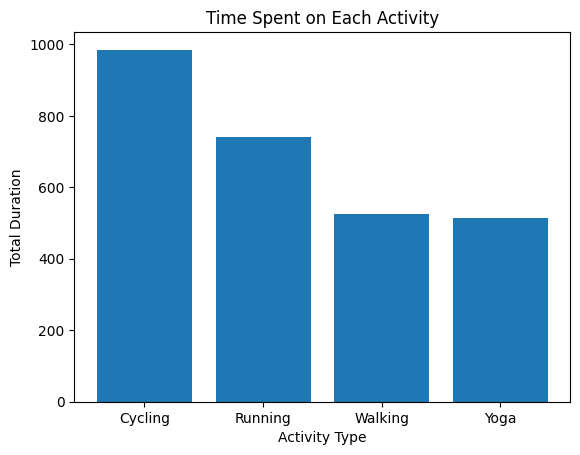

In [25]:
activity_time = df.groupby("Activity_Type")["Duration"].sum()

plt.bar(activity_time.index, activity_time.values)

plt.title("Time Spent on Each Activity")
plt.xlabel("Activity Type")
plt.ylabel("Total Duration")

plt.show()

Calories over time

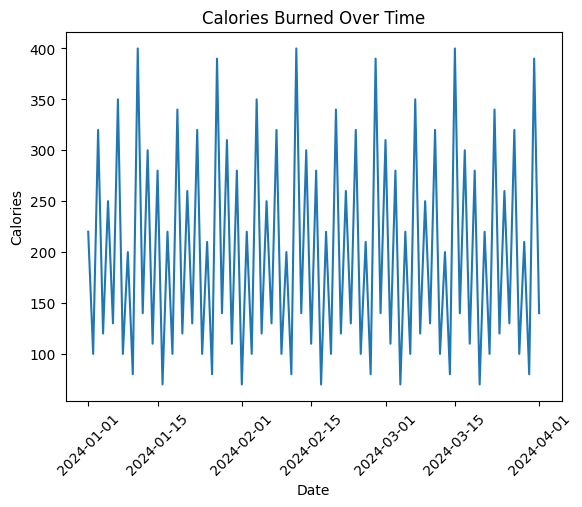

In [26]:
df["Date"] = pd.to_datetime(df["Date"])

daily_calories = df.groupby("Date")["Calories_Burned"].sum()

plt.plot(daily_calories.index, daily_calories.values)

plt.title("Calories Burned Over Time")
plt.xlabel("Date")
plt.ylabel("Calories")

plt.xticks(rotation=45)

plt.show()

Activity Distribution

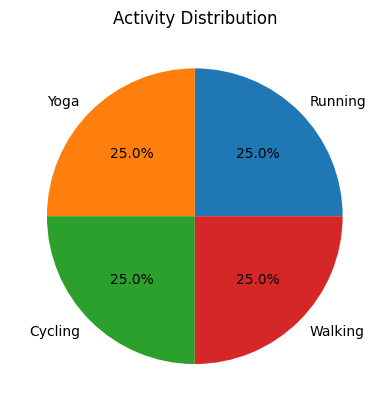

In [27]:
activity_count = df["Activity_Type"].value_counts()

plt.pie(activity_count.values, labels=activity_count.index, autopct="%1.1f%%")

plt.title("Activity Distribution")

plt.show()